# 03 — Full CTGAN retrain on the locked training partition

**Purpose.** Replace the reduced Week-1 CTGAN run with a full-row,
conditional retrain. Every candidate is trained only on the 40,642
locked training rows. Epoch-budget selection and augmentation-budget
selection use validation data; the fixed evaluation partition is not
scored here.

The research profile trains independent 100, 200, and 300 epoch
restarts from the same seed. This is more expensive than continuation,
but creates valid, reproducible checkpoint candidates because the
public CTGAN API does not expose safe optimizer-state resumption.

In [1]:
import json, os, platform, random, time, warnings
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, matthews_corrcoef

try:
    import torch
    from ctgan import CTGAN
except (ImportError, OSError) as exc:
    raise RuntimeError(
        "PyTorch/CTGAN could not load. On Windows use Python 3.11 and "
        "run setup_windows_cpu.ps1; do not reuse the broken Python 3.12 environment."
    ) from exc

sns.set_theme(style="whitegrid")
PROFILE = os.getenv("REVALIDATION_PROFILE", "research").strip().lower()
if PROFILE not in {"smoke", "research"}:
    raise ValueError("REVALIDATION_PROFILE must be smoke or research")
REPORTABLE = PROFILE == "research"
EPOCH_CANDIDATES = [5] if PROFILE == "smoke" else [100, 200, 300]
BUDGETS = [0.25, 0.50, 1.00]
VALIDATION_SAMPLE_PER_CLASS = 250 if PROFILE == "smoke" else 1_000
MAX_CONDITIONAL_ATTEMPTS = 50
print({"profile": PROFILE, "reportable": REPORTABLE, "epochs": EPOCH_CANDIDATES})

{'profile': 'research', 'reportable': True, 'epochs': [100, 200, 300]}


In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    starts = [Path.cwd().resolve()]
    try:
        starts.append(Path(__file__).resolve().parent)
    except NameError:
        pass
    for start in starts:
        for candidate in [start, *start.parents]:
            if candidate.name == "Marco_Revalidation_v2":
                return candidate
            nested = candidate / "Marco_Revalidation_v2"
            if (nested / "00_protocol").exists():
                return nested
    raise FileNotFoundError(
        "Could not locate Marco_Revalidation_v2. Run this notebook from inside "
        "the extracted project directory."
    )

PROJECT_ROOT = resolve_project_root()
CONTRACT_DIR = PROJECT_ROOT / "01_data_contract"
CLASSICAL_DIR = PROJECT_ROOT / "02_classical_augmentation" / "outputs"
CTGAN_DIR = PROJECT_ROOT / "03_ctgan"
QGAN_DIR = PROJECT_ROOT / "04_qgan"
FIDELITY_DIR = PROJECT_ROOT / "05_fidelity"
DOWNSTREAM_DIR = PROJECT_ROOT / "06_downstream"
HANDOFF_DIR = PROJECT_ROOT / "07_quantum_handoff"
REPORT_DIR = PROJECT_ROOT / "08_reporting"
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\HP\Desktop\Qintern\week5\Marco_Revalidation_v2


In [3]:
import sklearn

TARGET = "Label"
CLASS_ORDER = ["Benign", "Ransomware", "Spyware", "Trojan"]
MINORITY_CLASSES = ["Ransomware", "Spyware", "Trojan"]
SEED = 42
EXPECTED_SHA256 = "cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a"

required = {
    "clean": CONTRACT_DIR / "malmem2022_clean_locked.csv.gz",
    "split": CONTRACT_DIR / "split_manifest.csv",
    "preprocessor": CONTRACT_DIR / "preprocessing.joblib",
    "arrays": CONTRACT_DIR / "locked_preprocessed_splits.npz",
    "manifest": CONTRACT_DIR / "dataset_manifest.json",
}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Run Notebook 01 first. Missing:\n- " + "\n- ".join(missing))

dataset_manifest = json.loads(required["manifest"].read_text(encoding="utf-8"))
preprocessing = joblib.load(required["preprocessor"])
locked = np.load(required["arrays"])
clean = pd.read_csv(required["clean"], low_memory=False)

assert dataset_manifest["source_sha256"] == EXPECTED_SHA256
assert preprocessing["dataset_sha256"] == EXPECTED_SHA256
assert len(clean) == 58_062 and clean["row_id"].is_unique
assert clean["partition"].value_counts().to_dict() == {
    "train": 40_642, "validation": 8_710, "test": 8_710
}

retained_features = list(preprocessing["retained_features"])
X_train = locked["X_train"].astype(np.float64)
X_validation = locked["X_validation"].astype(np.float64)
X_test = locked["X_test"].astype(np.float64)
y_train = locked["y_train"].astype(str)
y_validation = locked["y_validation"].astype(str)
y_test = locked["y_test"].astype(str)
assert X_train.shape == (40_642, 52)
assert X_validation.shape == (8_710, 52)
assert X_test.shape == (8_710, 52)
assert np.isfinite(X_train).all() and np.isfinite(X_validation).all() and np.isfinite(X_test).all()
print("Locked contract verified:", X_train.shape, X_validation.shape, X_test.shape)

Locked contract verified: (40642, 52) (8710, 52) (8710, 52)


## 1. Prepare the full training table

CTGAN receives all 52 retained, standardized features plus the class
label as its only discrete column. Standardization is the frozen
training-only transform from Notebook 01; no validation/test row is
used to fit it.

In [4]:
OUTPUT_DIR = CTGAN_DIR / "outputs"
CHECKPOINT_DIR = CTGAN_DIR / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "epoch_candidates").mkdir(exist_ok=True)
(OUTPUT_DIR / "multiclass_budget").mkdir(exist_ok=True)
(OUTPUT_DIR / "selected").mkdir(exist_ok=True)
(OUTPUT_DIR / "matched").mkdir(exist_ok=True)

train_table = pd.DataFrame(X_train, columns=retained_features)
train_table[TARGET] = y_train
assert not train_table.isna().any().any()
assert len(train_table) == 40_642
display(train_table[TARGET].value_counts().reindex(CLASS_ORDER).to_frame("count"))

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

,count
Label,
Benign,20461
Ransomware,6670
Spyware,6870
Trojan,6641


## 2. Train independent epoch-budget checkpoints

Loss traces are descriptive diagnostics, not a stopping rule. Candidate
selection below uses a common validation-fidelity score. A model that
cannot produce the requested class condition is rejected explicitly.

In [5]:
def set_model_seed(model, seed):
    if hasattr(model, "set_random_state"):
        model.set_random_state(seed)

def sample_exact_class(model, class_name, n_rows, seed):
    set_model_seed(model, seed)
    accepted = []
    total_drawn = 0
    for attempt in range(MAX_CONDITIONAL_ATTEMPTS):
        needed = n_rows - sum(len(x) for x in accepted)
        if needed <= 0:
            break
        draw_n = max(500, min(10_000, needed * 3))
        candidate = model.sample(
            draw_n, condition_column=TARGET, condition_value=class_name
        )
        total_drawn += len(candidate)
        candidate = candidate[candidate[TARGET].astype(str).eq(class_name)]
        if len(candidate):
            accepted.append(candidate)
    if sum(len(x) for x in accepted) < n_rows:
        raise RuntimeError(
            f"CTGAN conditional sampling failed for {class_name}: "
            f"accepted {sum(len(x) for x in accepted)}/{n_rows} from {total_drawn} draws"
        )
    result = pd.concat(accepted, ignore_index=True).iloc[:n_rows].copy()
    result[retained_features] = result[retained_features].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(result[retained_features].to_numpy()).all():
        raise RuntimeError("Non-finite CTGAN sample")
    return result, total_drawn

checkpoint_rows = []
trained_models = {}
for epoch_count in EPOCH_CANDIDATES:
    print(f"Training full CTGAN restart: {epoch_count} epochs")
    seed_everything(SEED)
    model = CTGAN(
        epochs=epoch_count,
        batch_size=500,
        pac=10,
        embedding_dim=128,
        generator_dim=(256, 256),
        discriminator_dim=(256, 256),
        generator_lr=2e-4,
        discriminator_lr=2e-4,
        discriminator_steps=1,
        verbose=True,
        enable_gpu=torch.cuda.is_available(),
    )
    set_model_seed(model, SEED)
    started = time.perf_counter()
    model.fit(train_table, discrete_columns=[TARGET])
    fit_seconds = time.perf_counter() - started
    model_path = CHECKPOINT_DIR / f"ctgan_full_epoch_{epoch_count:03d}.pkl"
    model.save(str(model_path))

    loss = model.loss_values.copy()
    loss["candidate_epochs"] = epoch_count
    loss.to_csv(
        OUTPUT_DIR / "epoch_candidates" / f"loss_epoch_{epoch_count:03d}.csv",
        index=False,
    )

    class_metrics = []
    for class_index, class_name in enumerate(MINORITY_CLASSES):
        real_val = X_validation[y_validation == class_name]
        n_eval = min(VALIDATION_SAMPLE_PER_CLASS, len(real_val))
        synth, drawn = sample_exact_class(
            model, class_name, n_eval, SEED + 1000 * epoch_count + class_index
        )
        syn_values = synth[retained_features].to_numpy(float)
        real_values = real_val[:n_eval]
        ks_values = [ks_2samp(real_values[:, j], syn_values[:, j]).statistic
                     for j in range(real_values.shape[1])]
        w_values = [wasserstein_distance(real_values[:, j], syn_values[:, j])
                    for j in range(real_values.shape[1])]
        class_metrics.append((np.mean(ks_values), np.mean(w_values)))
    mean_ks = float(np.mean([x[0] for x in class_metrics]))
    mean_w = float(np.mean([x[1] for x in class_metrics]))
    checkpoint_rows.append({
        "epochs": epoch_count, "fit_seconds": fit_seconds,
        "validation_mean_ks": mean_ks,
        "validation_mean_wasserstein": mean_w,
        "selection_score": mean_ks + mean_w,
        "checkpoint": str(model_path.relative_to(PROJECT_ROOT)),
    })
    trained_models[epoch_count] = model

checkpoint_selection = pd.DataFrame(checkpoint_rows).sort_values(
    ["selection_score", "epochs"], ascending=[True, True]
).reset_index(drop=True)
checkpoint_selection.to_csv(OUTPUT_DIR / "checkpoint_validation_selection.csv", index=False)
display(checkpoint_selection)
selected_epochs = int(checkpoint_selection.iloc[0]["epochs"])
selected_model = trained_models[selected_epochs]
selected_model.save(str(CHECKPOINT_DIR / "ctgan_selected.pkl"))
print("Selected epoch budget:", selected_epochs)

Training full CTGAN restart: 100 epochs


Gen. (-01.09) | Discrim. (+00.63): 100%|██████████| 100/100 [13:36<00:00,  8.17s/it]


Training full CTGAN restart: 200 epochs


Gen. (-01.37) | Discrim. (+00.16): 100%|██████████| 200/200 [27:08<00:00,  8.14s/it]


Training full CTGAN restart: 300 epochs


Gen. (-01.04) | Discrim. (-00.26): 100%|██████████| 300/300 [42:42<00:00,  8.54s/it]


,epochs,fit_seconds,validation_mean_ks,validation_mean_wasserstein,selection_score,checkpoint
0,300,2716.647464,0.307744,0.149797,0.457541,03_ctgan\checkpoints\ctgan_full_epoch_300.pkl
1,200,1778.649246,0.314186,0.149081,0.463267,03_ctgan\checkpoints\ctgan_full_epoch_200.pkl
2,100,970.724821,0.361500,0.177929,0.539429,03_ctgan\checkpoints\ctgan_full_epoch_100.pkl


Selected epoch budget: 300


## 3. Generate the maximum class deficits once

Every lower budget is a deterministic prefix of the same maximum pool,
avoiding a change of random sample between budget comparisons.

In [6]:
train_counts = pd.Series(y_train).value_counts().reindex(CLASS_ORDER)
majority_count = int(train_counts.max())
full_additions = {
    c: majority_count - int(train_counts[c]) for c in MINORITY_CLASSES
}
max_frames = []
sampling_log = []
for index, (class_name, count) in enumerate(full_additions.items()):
    frame, drawn = sample_exact_class(
        selected_model, class_name, count, SEED + 90_000 + index
    )
    max_frames.append(frame)
    sampling_log.append({"class": class_name, "accepted": count, "drawn": drawn})
max_pool = pd.concat(max_frames, ignore_index=True)
pd.DataFrame(sampling_log).to_csv(OUTPUT_DIR / "conditional_sampling_log.csv", index=False)
assert Counter(max_pool[TARGET]) == Counter(full_additions)

def frame_for_budget(budget):
    pieces = []
    for class_name in MINORITY_CLASSES:
        requested = int(np.rint(budget * full_additions[class_name]))
        pieces.append(max_pool[max_pool[TARGET].eq(class_name)].iloc[:requested])
    return pd.concat(pieces, ignore_index=True)

def save_scaled(frame, path):
    np.savez_compressed(
        path,
        X_synthetic=frame[retained_features].to_numpy(np.float32),
        y_synthetic=frame[TARGET].to_numpy(str),
        retained_features=np.asarray(retained_features, str),
        method=np.asarray(["CTGAN"], str),
    )

# Reconstruct and constrain to training-observed original-space ranges.
feature_columns = list(preprocessing["feature_columns"])
retained_mask = np.asarray(preprocessing["retained_mask"], dtype=bool)
raw_train = clean.loc[clean.partition.eq("train"), feature_columns].apply(pd.to_numeric)
train_low = raw_train.min().to_numpy(float)
train_high = raw_train.max().to_numpy(float)

def reconstruct_constrained(X_scaled):
    retained_imputed = preprocessing["scaler"].inverse_transform(X_scaled)
    full = np.tile(preprocessing["imputer"].statistics_, (len(X_scaled), 1))
    full[:, retained_mask] = retained_imputed
    return np.clip(full, train_low, train_high)

budget_frames = {}
for budget in BUDGETS:
    pct = int(100 * budget)
    frame = frame_for_budget(budget)
    budget_frames[budget] = frame
    save_scaled(frame, OUTPUT_DIR / "multiclass_budget" / f"ctgan_budget_{pct:03d}_synthetic_scaled.npz")
    constrained = pd.DataFrame(
        reconstruct_constrained(frame[retained_features].to_numpy(float)),
        columns=feature_columns,
    )
    constrained.insert(0, TARGET, frame[TARGET].to_numpy(str))
    constrained.to_csv(
        OUTPUT_DIR / "multiclass_budget" / f"ctgan_budget_{pct:03d}_synthetic_constrained.csv.gz",
        index=False, compression="gzip",
    )

matched = max_pool[max_pool[TARGET].eq("Trojan")].iloc[:2000].copy()
save_scaled(matched, OUTPUT_DIR / "matched" / "matched_ctgan_synthetic_scaled.npz")

## 4. Select the CTGAN augmentation budget on validation only

In [7]:
validation_rows = []
for budget, frame in budget_frames.items():
    X_syn = frame[retained_features].to_numpy(float)
    y_syn = frame[TARGET].to_numpy(str)
    model = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1)
    model.fit(np.vstack([X_train, X_syn]), np.concatenate([y_train, y_syn]))
    pred = model.predict(X_validation)
    validation_rows.append({
        "budget": budget, "synthetic_rows": len(frame),
        "validation_macro_f1": f1_score(y_validation, pred, average="macro", zero_division=0),
        "validation_mcc": matthews_corrcoef(y_validation, pred),
    })
validation_results = pd.DataFrame(validation_rows).sort_values(
    ["validation_macro_f1", "budget"], ascending=[False, True]
).reset_index(drop=True)
validation_results.to_csv(OUTPUT_DIR / "validation_budget_selection.csv", index=False)
selected_budget = float(validation_results.iloc[0]["budget"])
selected_frame = budget_frames[selected_budget]
save_scaled(selected_frame, OUTPUT_DIR / "selected" / "selected_ctgan_synthetic_scaled.npz")
selected_constrained = pd.DataFrame(
    reconstruct_constrained(selected_frame[retained_features].to_numpy(float)),
    columns=feature_columns,
)
selected_constrained.insert(0, TARGET, selected_frame[TARGET].to_numpy(str))
selected_constrained.to_csv(
    OUTPUT_DIR / "selected" / "selected_ctgan_synthetic_constrained.csv.gz",
    index=False, compression="gzip",
)
display(validation_results)
print("Selected CTGAN budget:", selected_budget)
print("TEST LABELS ACCESSED FOR SCORING: False")

,budget,synthetic_rows,validation_macro_f1,validation_mcc
0,1.00,41202,0.806366,0.807137
1,0.25,10301,0.804076,0.804885
2,0.50,20602,0.802721,0.803507


Selected CTGAN budget: 1.0
TEST LABELS ACCESSED FOR SCORING: False


## 5. Diagnostics, manifest, and hard acceptance checks

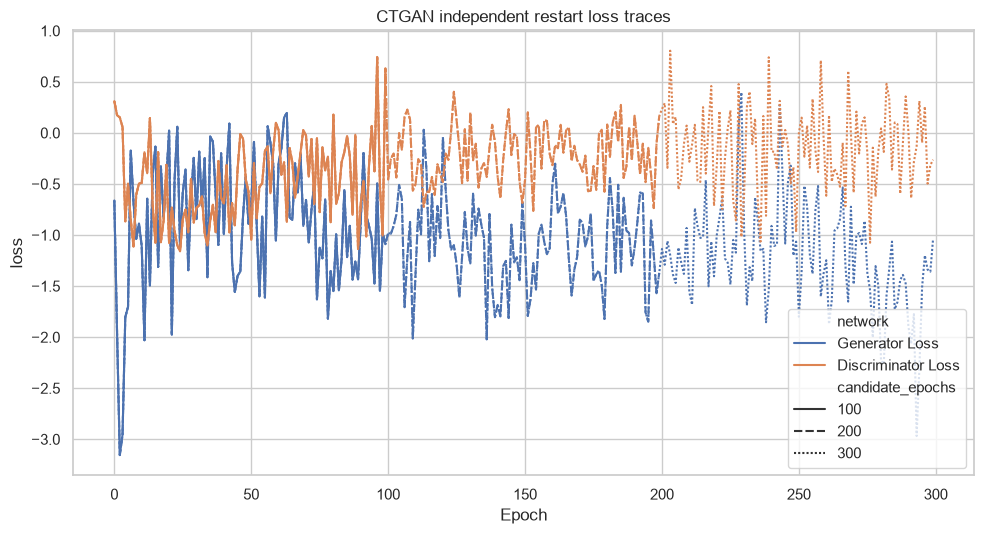

CTGAN STAGE ACCEPTED {'protocol_version': 'revalidation_v2_ctgan_v1', 'created_at_utc': '2026-08-11T21:39:42.680696+00:00', 'profile': 'research', 'reportable': True, 'dataset_sha256': 'cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a', 'training_partition_rows': 40642, 'training_partition_only': True, 'epoch_candidates_independent_restarts': [100, 200, 300], 'selected_epochs': 300, 'checkpoint_selection_metric': 'validation_mean_ks + validation_mean_wasserstein', 'selected_budget': 1.0, 'budget_selection_metric': 'validation_macro_f1', 'selected_synthetic_counts': {'Ransomware': 13791, 'Spyware': 13591, 'Trojan': 13820}, 'selected_unique_fraction_rounded_10dp': 1.0, 'test_scored': False, 'software': {'python': '3.12.0', 'torch': '2.13.0+cpu'}, 'limitations': ['Independent restart checkpoints are computationally expensive but resumable-state safe.', 'Twelve feature-equivalent groups cross the locked comparability split.']}


In [8]:
all_loss = pd.concat([
    pd.read_csv(p) for p in sorted((OUTPUT_DIR / "epoch_candidates").glob("loss_epoch_*.csv"))
], ignore_index=True)
loss_long = all_loss.melt(
    id_vars=["Epoch", "candidate_epochs"],
    value_vars=["Generator Loss", "Discriminator Loss"],
    var_name="network", value_name="loss",
)
plt.figure(figsize=(10, 5.5))
sns.lineplot(data=loss_long, x="Epoch", y="loss", hue="network", style="candidate_epochs")
plt.title("CTGAN independent restart loss traces")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "01_ctgan_loss_traces.png", dpi=180); plt.show()

selected_counts = selected_frame[TARGET].value_counts().reindex(MINORITY_CLASSES, fill_value=0)
selected_values = selected_frame[retained_features].to_numpy(float)
unique_fraction = len(np.unique(np.round(selected_values, 10), axis=0)) / len(selected_values)
assert np.isfinite(selected_values).all()
assert unique_fraction > 0.98
assert set(selected_counts.index) == set(MINORITY_CLASSES)

manifest = {
    "protocol_version": "revalidation_v2_ctgan_v1",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "profile": PROFILE, "reportable": REPORTABLE,
    "dataset_sha256": EXPECTED_SHA256,
    "training_partition_rows": len(X_train),
    "training_partition_only": True,
    "epoch_candidates_independent_restarts": EPOCH_CANDIDATES,
    "selected_epochs": selected_epochs,
    "checkpoint_selection_metric": "validation_mean_ks + validation_mean_wasserstein",
    "selected_budget": selected_budget,
    "budget_selection_metric": "validation_macro_f1",
    "selected_synthetic_counts": selected_counts.astype(int).to_dict(),
    "selected_unique_fraction_rounded_10dp": unique_fraction,
    "test_scored": False,
    "software": {"python": platform.python_version(), "torch": torch.__version__},
    "limitations": [
        "Independent restart checkpoints are computationally expensive but resumable-state safe.",
        "Twelve feature-equivalent groups cross the locked comparability split.",
    ],
}
(OUTPUT_DIR / "ctgan_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
(OUTPUT_DIR / "README.md").write_text(
    f"# CTGAN output\n\nProfile: {PROFILE}; reportable: {REPORTABLE}.\n"
    f"Selected epochs: {selected_epochs}. Selected budget: {selected_budget:.0%}.\n"
    "Test scoring: false.\n", encoding="utf-8"
)
print("CTGAN STAGE ACCEPTED", manifest)